<a href="https://colab.research.google.com/github/felipealencar/courses/blob/artificial-intelligence/artificial-intelligence/lec-06/model_evaluation_trees.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 06 — Model evaluation, decision trees & random forests

**Course:** Artificial Intelligence · prof. Felipe Alencar · IFAL — Arapiraca

## Learning objectives
1. Train **decision trees** and **random forests**.
2. Diagnose **overfitting** with a train-vs-test curve over tree depth.
3. Estimate generalization with **k-fold cross-validation**.
4. Read **feature importance** and a **ROC curve / AUC**.

We continue the **rain vs. no-rain** task from lecture 05 (Maceió daily weather),
now focusing on *how to evaluate models honestly*.

In [1]:
import os
import pandas as pd

# Make plots show up inline and look consistent across the course.
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9, 5)

RAW_BASE = ("https://raw.githubusercontent.com/felipealencar/courses/"
            "artificial-intelligence/datasets/")

def load_dataset(name):
    """Load a course dataset by file name from the local catalog or GitHub."""
    here = os.getcwd()
    for _ in range(6):
        local = os.path.join(here, "datasets", name)
        if os.path.exists(local):
            return pd.read_csv(local)
        here = os.path.dirname(here)
    return pd.read_csv(RAW_BASE + name)  # Colab / standalone fallback


In [2]:
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, RocCurveDisplay

wx = load_dataset("maceio_daily_weather.csv")
features = ["temp_max_c", "temp_min_c", "temp_mean_c", "humidity_pct",
            "pressure_hpa", "wind_max_kmh", "solar_rad_mj_m2", "month"]
X = wx[features].values
y = wx["rained"].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

## 1. Overfitting, made visible

A decision tree can grow until it memorizes the training set. We vary
`max_depth` and watch **training accuracy** keep rising while **test accuracy**
peaks and then *falls* — the signature of overfitting.

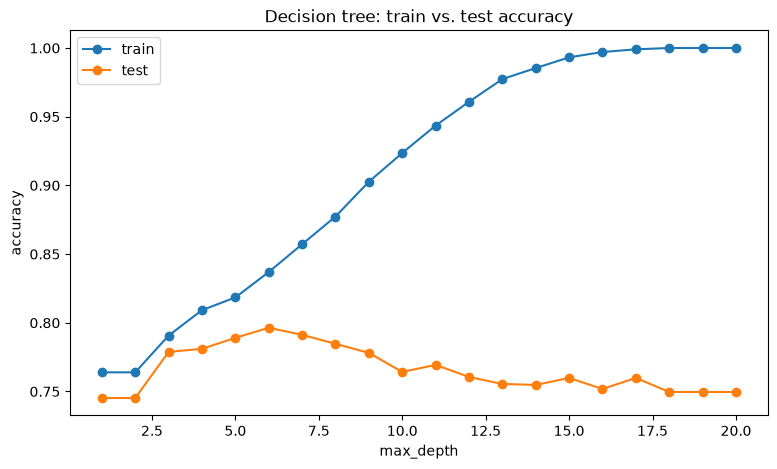

best depth on test set: 6


In [3]:
depths = range(1, 21)
train_acc, test_acc = [], []
for d in depths:
    t = DecisionTreeClassifier(max_depth=d, random_state=0).fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, t.predict(X_train)))
    test_acc.append(accuracy_score(y_test, t.predict(X_test)))

plt.plot(list(depths), train_acc, marker="o", label="train")
plt.plot(list(depths), test_acc, marker="o", label="test")
plt.title("Decision tree: train vs. test accuracy")
plt.xlabel("max_depth"); plt.ylabel("accuracy"); plt.legend(); plt.show()
best_d = list(depths)[int(np.argmax(test_acc))]
print("best depth on test set:", best_d)

## 2. Cross-validation — a more honest estimate

A single train/test split is noisy. **k-fold CV** rotates the test fold so every
sample is used for evaluation once, giving a mean ± std estimate.

In [4]:
tree = DecisionTreeClassifier(max_depth=best_d, random_state=0)
scores = cross_val_score(tree, X, y, cv=5, scoring="accuracy")
print("5-fold accuracies:", np.round(scores, 3))
print(f"mean = {scores.mean():.3f}  ±  {scores.std():.3f}")

5-fold accuracies: [0.812 0.811 0.789 0.741 0.754]
mean = 0.782  ±  0.029


## 3. Random forest — many trees vote

A **random forest** averages many decorrelated trees. It usually generalizes
better than a single tree and exposes useful **feature importances**.

Random forest test accuracy = 0.822


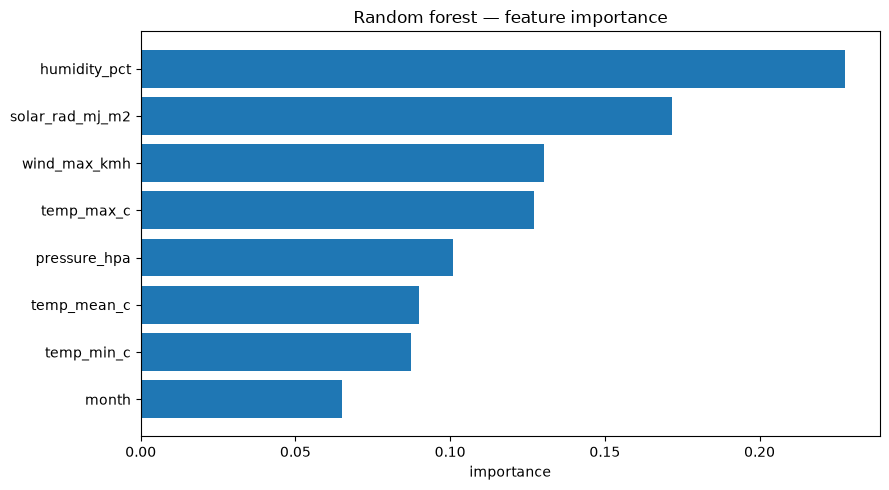

In [5]:
rf = RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=-1)
rf.fit(X_train, y_train)
print(f"Random forest test accuracy = {accuracy_score(y_test, rf.predict(X_test)):.3f}")

imp = sorted(zip(features, rf.feature_importances_), key=lambda t: t[1])
names = [n for n, _ in imp]; vals = [v for _, v in imp]
plt.barh(names, vals)
plt.title("Random forest — feature importance")
plt.xlabel("importance"); plt.tight_layout(); plt.show()

## 4. ROC curve and AUC

Accuracy uses a fixed 0.5 threshold. The **ROC curve** shows the trade-off
between true-positive and false-positive rates across *all* thresholds; **AUC**
summarizes it (0.5 = random, 1.0 = perfect).

ROC AUC = 0.893


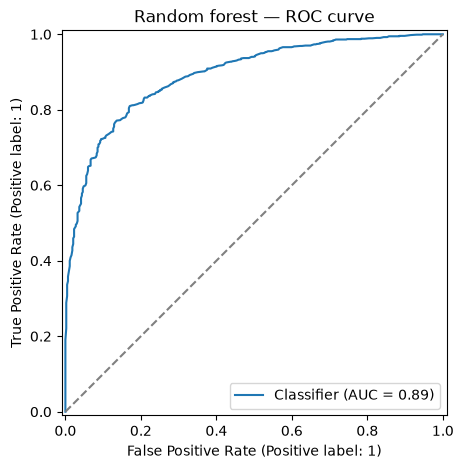

In [6]:
proba = rf.predict_proba(X_test)[:, 1]
print(f"ROC AUC = {roc_auc_score(y_test, proba):.3f}")
RocCurveDisplay.from_predictions(y_test, proba)
plt.plot([0, 1], [0, 1], "--", color="gray")
plt.title("Random forest — ROC curve"); plt.show()

## What did we learn?
- **Overfitting** is real and visible: training accuracy is an optimistic liar.
- **Cross-validation** gives a more trustworthy performance estimate with an
  uncertainty band.
- **Random forests** are a strong, low-tuning baseline and tell you *which
  features matter* (here, humidity and pressure dominate rain prediction —
  physically sensible!).
- **ROC/AUC** evaluate a classifier independently of any single threshold.

### Exercises
1. Replace accuracy with `scoring="f1"` in cross-validation. Does the ranking of
   `max_depth` change? Why might F1 be the better target here?
2. Vary `n_estimators` in the forest over `[10, 50, 100, 300, 600]`. Plot test
   AUC. Where do the gains flatten out?
3. Train the forest using **only the top-3 important features**. How much accuracy
   do you lose for a much simpler model?
4. **Discuss:** feature importance says *what the model uses*, not *what causes
   rain*. Give an example where those two could disagree.